In [12]:
pip install conllu pandas scipy numpy statsmodels matplotlib seaborn requests


In [13]:
import conllu
import math
import pandas as pd
import numpy as np
from collections import Counter
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [14]:
# All files exactly as they appear in your Colab sidebar
language_files = {
    "English":  ["en_gum-sud-train.conllu"],
    "French":   ["fr_gsd-sud-train_A.conllu",
                 "fr_gsd-sud-train_B.conllu",
                 "fr_gsd-sud-train_C.conllu",
                 "fr_gsd-sud-train_D.conllu",
                 "fr_gsd-sud-train_E.conllu"],
    "German":   ["de_gsd-sud-train.conllu"],
    "Hindi":    ["hi_hdtb-sud-train.conllu"],
    "Japanese": ["ja_gsd-sud-train.conllu"],
    "Persian":  ["fa_seraji-sud-train.conllu"],
    "Russian":  ["ru_syntagrus-sud-train.conllu"],
    "Turkish":  ["tr_kenet-sud-train.conllu"],
    "Chinese":  ["zh_gsd-sud-train.conllu"],
}

# Typology grouping for your hypothesis
typology_map = {
    "English":  "SVO",
    "French":   "SVO",
    "Chinese":  "SVO",
    "German":   "Mixed",
    "Russian":  "Mixed",
    "Hindi":    "SOV",
    "Japanese": "SOV",
    "Persian":  "SOV",
    "Turkish":  "SOV",
}

In [15]:
def load_sentences(filepaths):
    """Load one or more .conllu files and return all sentences."""
    all_sentences = []
    for path in filepaths:
        with open(path, "r", encoding="utf-8") as f:
            all_sentences += conllu.parse(f.read())
    print(f"  Loaded {len(all_sentences)} sentences from {filepaths}")
    return all_sentences

In [16]:
def extract_pairs(sentences):
    """
    For each dependency arc in every sentence, extract:
    - head word
    - dependent word
    - dependency distance (absolute difference in positions)
    """
    pairs = []
    for sent in sentences:
        # Build a lookup: token id → token
        tokens = {tok["id"]: tok for tok in sent if isinstance(tok["id"], int)}

        for tok in sent:
            if not isinstance(tok["id"], int):
                continue  # skip multi-word tokens

            head_id = tok["head"]

            if head_id is None or head_id == 0:
                continue  # skip root

            if head_id not in tokens:
                continue  # skip if head not found

            head_word = tokens[head_id]["form"].lower().strip()
            dep_word  = tok["form"].lower().strip()
            dd        = abs(tok["id"] - head_id)  # Dependency Distance

            # Skip punctuation or empty tokens
            if not head_word.isalpha() or not dep_word.isalpha():
                continue

            pairs.append((head_word, dep_word, dd))

    print(f"  Extracted {len(pairs)} head-dependent pairs")
    return pairs

In [17]:
def compute_pmi(pairs, min_count=5):
    """
    Compute Pointwise Mutual Information for each (head, dependent) pair.
    min_count=5 filters rare pairs to avoid noisy PMI scores.

    PMI(h,d) = log2[ P(h,d) / (P(h) * P(d)) ]
    """
    pair_counts = Counter((h, d) for h, d, _ in pairs)
    head_counts = Counter(h for h, d, _ in pairs)
    dep_counts  = Counter(d for h, d, _ in pairs)
    total       = sum(pair_counts.values())

    pmi_scores = {}
    for (h, d), c in pair_counts.items():
        if c < min_count:
            continue  # filter rare pairs

        p_hd = c / total
        p_h  = head_counts[h] / total
        p_d  = dep_counts[d] / total

        pmi_scores[(h, d)] = math.log2(p_hd / (p_h * p_d))

    print(f"  Computed PMI for {len(pmi_scores)} unique pairs (min_count={min_count})")
    return pmi_scores

In [18]:
def build_dataframe(pairs, pmi_scores, language, typology):
    """Combine pairs with their PMI scores into a DataFrame."""
    rows = []
    for h, d, dd in pairs:
        pmi = pmi_scores.get((h, d))
        if pmi is not None:
            rows.append({
                "head":     h,
                "dep":      d,
                "DD":       dd,
                "PMI":      pmi,
                "language": language,
                "typology": typology,
            })

    df = pd.DataFrame(rows)
    print(f"  Final DataFrame: {len(df)} rows")
    return df

In [20]:
all_results = {}   # stores correlation results
all_dfs     = []   # stores dataframes for all languages

for lang, filepaths in language_files.items():
    print(f"\n{'='*40}")
    print(f"Processing: {lang}")
    print(f"{'='*40}")

    # Step 1: Load
    sentences = load_sentences(filepaths)

    # Step 2: Extract pairs
    pairs = extract_pairs(sentences)

    # Step 3: Compute PMI
    pmi_scores = compute_pmi(pairs, min_count=5)

    # Step 4: Build DataFrame
    typology = typology_map[lang]
    df = build_dataframe(pairs, pmi_scores, lang, typology)

    # Step 5: Spearman Correlation
    if len(df) > 10:
        corr, pval = spearmanr(df["PMI"], df["DD"])
        print(f"  Spearman r = {corr:.4f}, p-value = {pval:.6f}")
        all_results[lang] = {
            "language": lang,
            "typology": typology,
            "spearman_r": corr,
            "p_value": pval,
            "n_pairs": len(df)
        }
        all_dfs.append(df)
    else:
        print(f"  Skipping {lang} — not enough data")

print("\n\nDONE! All languages processed.")


Processing: English
  Loaded 10224 sentences from ['en_gum-sud-train.conllu']
  Extracted 130345 head-dependent pairs
  Computed PMI for 3153 unique pairs (min_count=5)
  Final DataFrame: 36231 rows
  Spearman r = -0.2128, p-value = 0.000000

Processing: French
  Loaded 14450 sentences from ['fr_gsd-sud-train_A.conllu', 'fr_gsd-sud-train_B.conllu', 'fr_gsd-sud-train_C.conllu', 'fr_gsd-sud-train_D.conllu', 'fr_gsd-sud-train_E.conllu']
  Extracted 263314 head-dependent pairs
  Computed PMI for 6957 unique pairs (min_count=5)
  Final DataFrame: 94203 rows
  Spearman r = -0.2727, p-value = 0.000000

Processing: German
  Loaded 13813 sentences from ['de_gsd-sud-train.conllu']
  Extracted 206406 head-dependent pairs
  Computed PMI for 3359 unique pairs (min_count=5)
  Final DataFrame: 37741 rows
  Spearman r = -0.1281, p-value = 0.000000

Processing: Hindi
  Loaded 13306 sentences from ['hi_hdtb-sud-train.conllu']
  Extracted 2265 head-dependent pairs
  Computed PMI for 91 unique pairs (min

In [21]:
results_df = pd.DataFrame(all_results.values())
results_df = results_df.sort_values("spearman_r")
results_df["significant"] = results_df["p_value"] < 0.05

print(results_df[["language", "typology", "spearman_r", "p_value", "significant", "n_pairs"]].to_string(index=False))

language typology  spearman_r       p_value  significant  n_pairs
   Hindi      SOV   -0.405041  1.781501e-58         True     1453
 Persian      SOV   -0.380883  0.000000e+00         True    25543
Japanese      SOV   -0.354848  0.000000e+00         True    55962
 Chinese      SVO   -0.312951 3.611038e-291         True    12905
 Russian    Mixed   -0.290311  0.000000e+00         True   222612
  French      SVO   -0.272664  0.000000e+00         True    94203
 English      SVO   -0.212801  0.000000e+00         True    36231
  German    Mixed   -0.128102 8.135260e-138         True    37741
 Turkish      SOV   -0.095134  4.706061e-09         True     3776


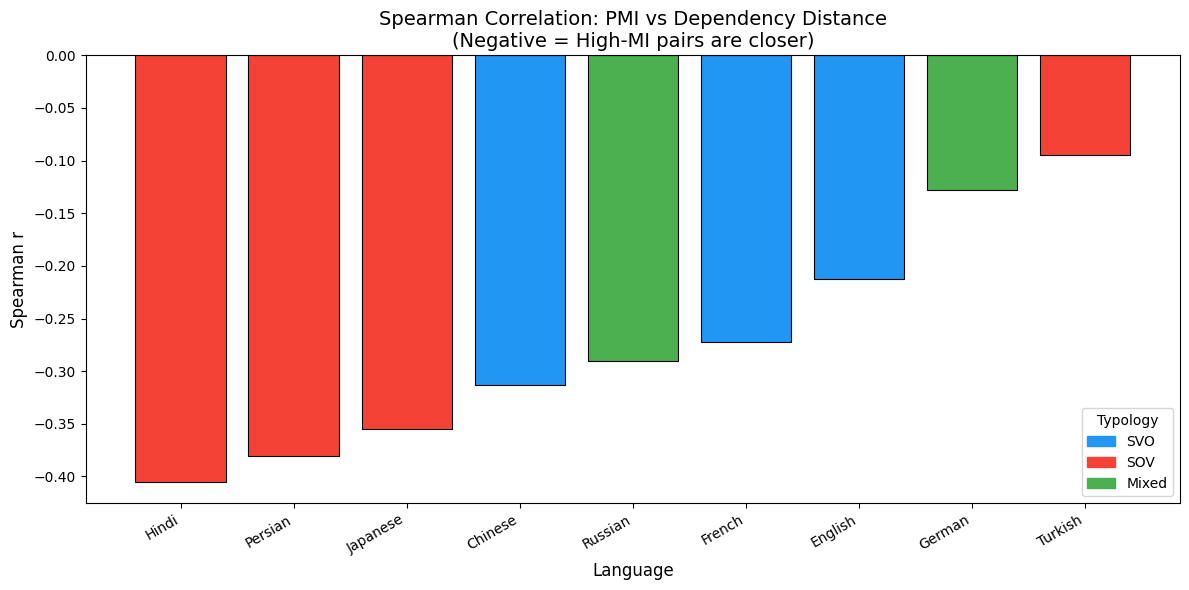

Saved: correlation_by_language.png


In [22]:
plt.figure(figsize=(12, 6))
colors = {"SVO": "#2196F3", "SOV": "#F44336", "Mixed": "#4CAF50"}

bars = plt.bar(
    results_df["language"],
    results_df["spearman_r"],
    color=[colors[t] for t in results_df["typology"]],
    edgecolor="black", linewidth=0.8
)

plt.axhline(0, color="black", linewidth=1.2, linestyle="--")
plt.title("Spearman Correlation: PMI vs Dependency Distance\n(Negative = High-MI pairs are closer)", fontsize=14)
plt.xlabel("Language", fontsize=12)
plt.ylabel("Spearman r", fontsize=12)
plt.xticks(rotation=30, ha="right")

# Add legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=t) for t, c in colors.items()]
plt.legend(handles=legend, title="Typology")

plt.tight_layout()
plt.savefig("correlation_by_language.png", dpi=150)
plt.show()
print("Saved: correlation_by_language.png")

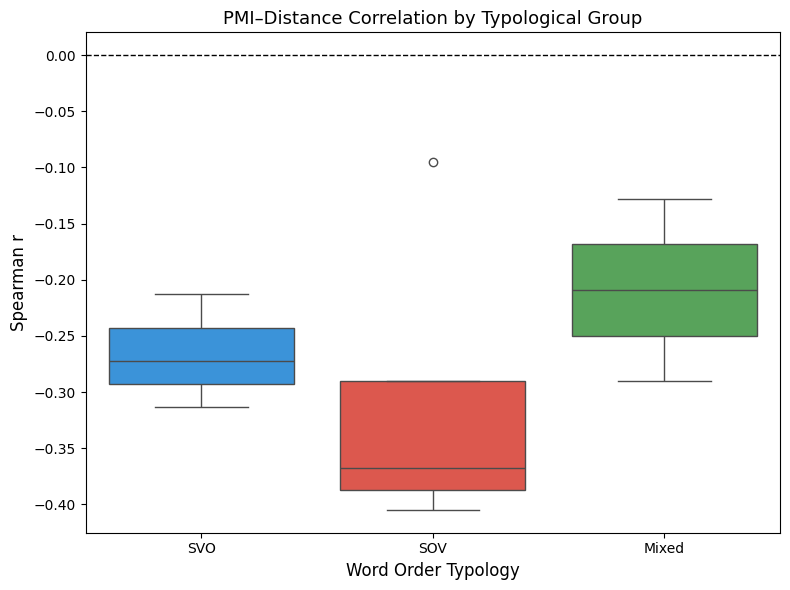

Saved: correlation_by_typology.png


In [23]:
plt.figure(figsize=(8, 6))
typology_order = ["SVO", "SOV", "Mixed"]

sns.boxplot(
    data=results_df,
    x="typology", y="spearman_r",
    order=typology_order,
    palette={"SVO": "#2196F3", "SOV": "#F44336", "Mixed": "#4CAF50"}
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("PMI–Distance Correlation by Typological Group", fontsize=13)
plt.xlabel("Word Order Typology", fontsize=12)
plt.ylabel("Spearman r", fontsize=12)
plt.tight_layout()
plt.savefig("correlation_by_typology.png", dpi=150)
plt.show()
print("Saved: correlation_by_typology.png")

In [24]:
!pip install statsmodels

import statsmodels.formula.api as smf

# Combine all language DataFrames
combined = pd.concat(all_dfs, ignore_index=True)

# Sample for speed if dataset is huge (optional)
if len(combined) > 500000:
    combined = combined.sample(500000, random_state=42)
    print("Sampled 500,000 rows for model fitting")

print(f"Total rows for model: {len(combined)}")

# Fit Linear Mixed-Effects Model
# Fixed effects: PMI, typology | Random effect: language
model  = smf.mixedlm("DD ~ PMI + C(typology)", combined, groups=combined["language"])
fitted = model.fit(method="lbfgs")

print(fitted.summary())

Total rows for model: 490426


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                 Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       DD    
No. Observations:        490426        Method:                   REML  
No. Groups:              9             Scale:                    9.7317
Min. group size:         1453          Log-Likelihood:           inf   
Max. group size:         222612        Converged:                Yes   
Mean group size:         54491.8                                       
-----------------------------------------------------------------------
                   Coef.   Std.Err.    z     P>|z|   [0.025     0.975] 
-----------------------------------------------------------------------
Intercept           5.524                                              
C(typology)[T.SOV]  9.830 33792.059    0.000 1.000 -66221.390 66241.049
C(typology)[T.SVO] -9.526                                              
PMI                -0.214     0.002 -130.493 0.000     -0.217    -0.210
Group Var

In [25]:
# Save correlation results to CSV
results_df.to_csv("correlation_results.csv", index=False)
print("Saved: correlation_results.csv")

# Save combined data (optional, can be large)
combined[["language","typology","PMI","DD"]].to_csv("combined_data.csv", index=False)
print("Saved: combined_data.csv")

Saved: correlation_results.csv
Saved: combined_data.csv


  Loaded 10224 sentences from ['en_gum-sud-train.conllu']
  Computed PMI for 3153 unique pairs (min_count=5)
       deprel  spearman_r       p_value    n
udep@unmarked   -0.670704  1.553416e-08   56
          mod   -0.501858 1.073935e-235 3706
         udep   -0.417879 2.136943e-196 4660
         flat   -0.232816  4.685164e-03  146
          det   -0.193372  1.552838e-52 6108
comp:aux@pass   -0.189555  1.199043e-02  175
     mod@poss   -0.188341  2.178810e-04  381
    mod@relcl   -0.139903  1.109895e-01  131
    discourse   -0.113373  5.858284e-02  279
         subj   -0.110751  1.237709e-15 5189
   reparandum   -0.096766  1.900871e-01  185
     comp:aux   -0.067386  7.467835e-03 1575
   conj:coord   -0.063808  1.222133e-01  588
    parataxis   -0.052470  4.805438e-01  183
           cc   -0.031047  2.128132e-01 1612
     comp:obl   -0.012407  6.806327e-01 1103
     compound   -0.007490  8.756508e-01  439
    subj@pass    0.017509  7.326787e-01  383
 compound@prt    0.021914  7.504946e

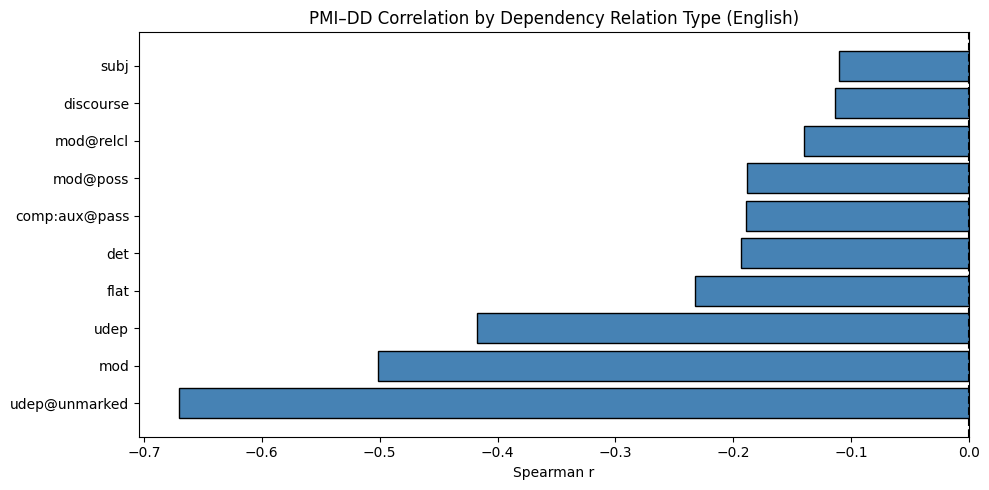

In [26]:
def extract_pairs_with_deprel(sentences):
    """Extract pairs WITH dependency relation type."""
    pairs = []
    for sent in sentences:
        tokens = {tok["id"]: tok for tok in sent if isinstance(tok["id"], int)}
        for tok in sent:
            if not isinstance(tok["id"], int): continue
            head_id = tok["head"]
            if head_id is None or head_id == 0: continue
            if head_id not in tokens: continue
            h  = tokens[head_id]["form"].lower().strip()
            d  = tok["form"].lower().strip()
            if not h.isalpha() or not d.isalpha(): continue
            dd     = abs(tok["id"] - head_id)
            deprel = tok["deprel"]          # e.g. "nsubj", "obj", "amod"
            pairs.append((h, d, dd, deprel))
    return pairs

# Run for English
sents_en = load_sentences(language_files["English"])
pairs_en = extract_pairs_with_deprel(sents_en)
pmi_en   = compute_pmi([(h,d,dd) for h,d,dd,_ in pairs_en])

rows = []
for h, d, dd, deprel in pairs_en:
    pmi = pmi_en.get((h, d))
    if pmi is not None:
        rows.append({"head": h, "dep": d, "DD": dd,
                     "PMI": pmi, "deprel": deprel})

deprel_df = pd.DataFrame(rows)

# Correlation per dependency type
deprel_results = []
for rel, grp in deprel_df.groupby("deprel"):
    if len(grp) < 50: continue
    r, p = spearmanr(grp["PMI"], grp["DD"])
    deprel_results.append({"deprel": rel, "spearman_r": r,
                            "p_value": p, "n": len(grp)})

deprel_res = pd.DataFrame(deprel_results).sort_values("spearman_r")
print(deprel_res.to_string(index=False))

# Plot top 10 strongest relations
top = deprel_res.head(10)
plt.figure(figsize=(10, 5))
plt.barh(top["deprel"], top["spearman_r"],
         color="steelblue", edgecolor="black")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Spearman r")
plt.title("PMI–DD Correlation by Dependency Relation Type (English)")
plt.tight_layout()
plt.savefig("deprel_correlation.png", dpi=150)
plt.show()

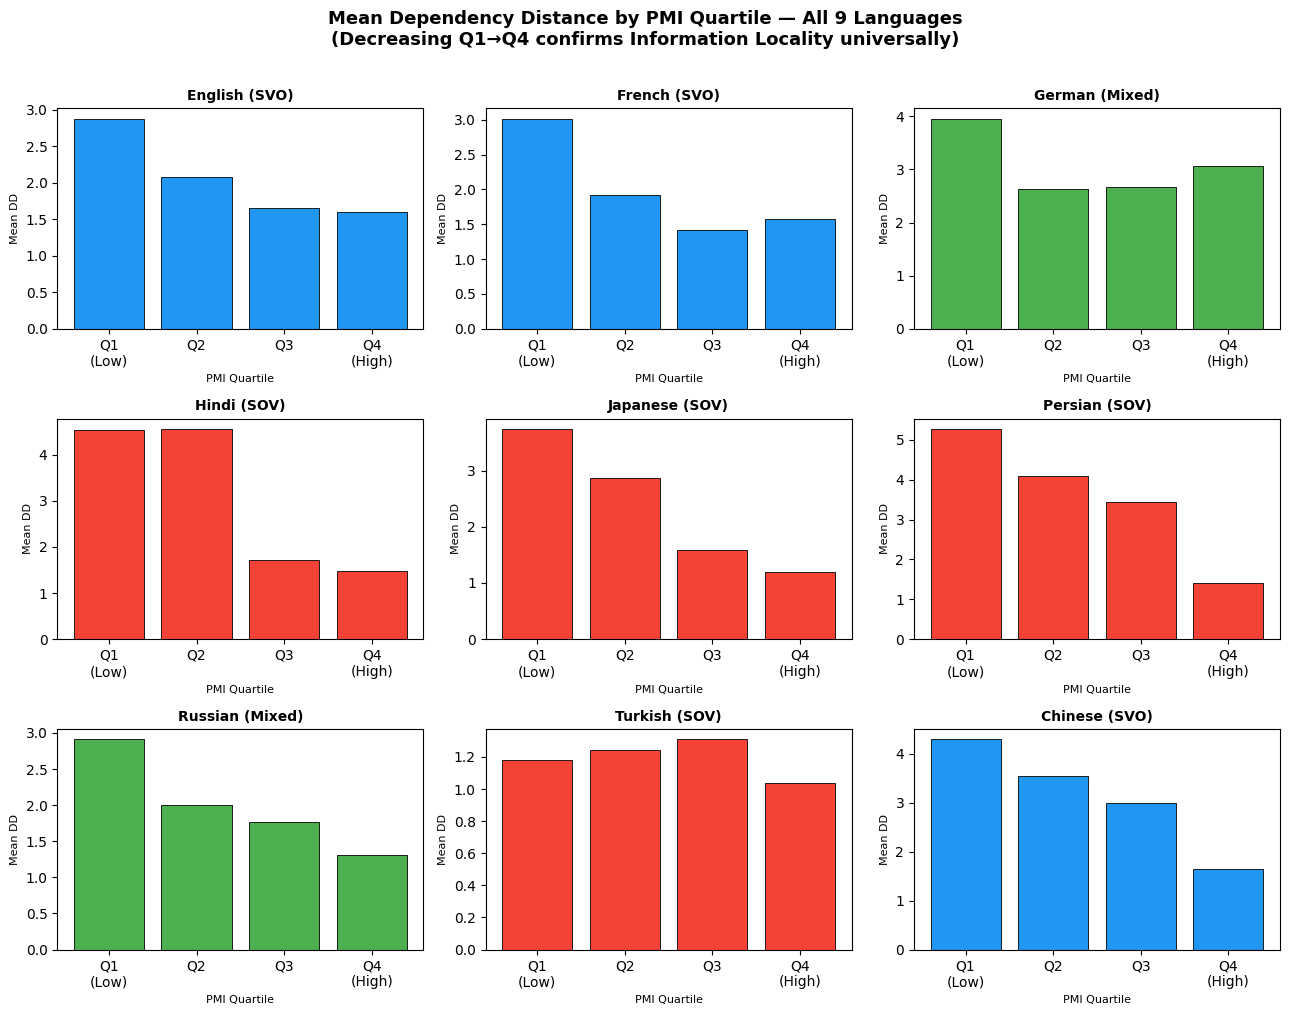

In [30]:
quartile_data = []

# Use all_dfs (the list) instead of all_results
for df in all_dfs:
    lang = df["language"].iloc[0]      # get language name from the df itself
    typ  = df["typology"].iloc[0]

    df2 = df.copy()
    df2["pmi_quartile"] = pd.qcut(df2["PMI"], q=4,
                           labels=["Q1\n(Low)","Q2","Q3","Q4\n(High)"])
    means = df2.groupby("pmi_quartile", observed=True)["DD"].mean()

    for q, mean_dd in means.items():
        quartile_data.append({
            "language": lang,
            "typology": typ,
            "quartile": q,
            "mean_DD":  mean_dd
        })

qdf = pd.DataFrame(quartile_data)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()
colors_t = {"SVO":"#2196F3","SOV":"#F44336","Mixed":"#4CAF50"}

for i, lang in enumerate(language_files.keys()):
    sub = qdf[qdf["language"] == lang]
    typ = typology_map[lang]
    axes[i].bar(sub["quartile"], sub["mean_DD"],
                color=colors_t[typ], edgecolor="black", linewidth=0.6)
    axes[i].set_title(f"{lang} ({typ})", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("PMI Quartile", fontsize=8)
    axes[i].set_ylabel("Mean DD", fontsize=8)

plt.suptitle(
    "Mean Dependency Distance by PMI Quartile — All 9 Languages\n"
    "(Decreasing Q1→Q4 confirms Information Locality universally)",
    fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("dd_by_pmi_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
summary_rows = []

for df in all_dfs:
    lang   = df["language"].iloc[0]
    typ    = df["typology"].iloc[0]
    median = df["PMI"].median()

    low_dd  = df[df["PMI"] <= median]["DD"].mean()
    high_dd = df[df["PMI"] >  median]["DD"].mean()

    summary_rows.append({
        "Language":           lang,
        "Typology":           typ,
        "Mean DD (Low PMI)":  round(low_dd,  3),
        "Mean DD (High PMI)": round(high_dd, 3),
        "Reduction":          round(low_dd - high_dd, 3),
        "% Reduction":        round((low_dd - high_dd) / low_dd * 100, 1),
    })

summary_df = (pd.DataFrame(summary_rows)
              .sort_values("% Reduction", ascending=False))

print(summary_df.to_string(index=False))
summary_df.to_csv("dd_pmi_summary.csv", index=False)
print("\nSaved: dd_pmi_summary.csv")

Language Typology  Mean DD (Low PMI)  Mean DD (High PMI)  Reduction  % Reduction
   Hindi      SOV              4.555               1.596      2.958         65.0
Japanese      SOV              3.317               1.393      1.924         58.0
 Persian      SOV              4.684               2.426      2.258         48.2
 Chinese      SVO              3.918               2.316      1.602         40.9
  French      SVO              2.468               1.499      0.969         39.3
 Russian    Mixed              2.458               1.537      0.921         37.5
 English      SVO              2.479               1.625      0.853         34.4
  German    Mixed              3.297               2.873      0.424         12.9
 Turkish      SOV              1.211               1.172      0.039          3.3

Saved: dd_pmi_summary.csv
